# ❤️ Heart Disease Prediction System
### End-to-End Machine Learning Pipeline

**Dataset:** Heart Disease UCI (Multi-Source) — Cleveland, Hungary, Switzerland, VA Long Beach  
**Target:** Predict presence of heart disease (`num` column: 0 = No Disease, 1–4 = Disease)  
**Stack:** Python · Scikit-learn · Imbalanced-learn · Pandas · Matplotlib · Seaborn

---
> 📁 Place `heart.csv` in the same folder as this notebook before running.

## 1. Import Libraries

In [9]:
# ================================
# 1. Import Libraries
# ================================
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.impute              import SimpleImputer
from sklearn.pipeline            import Pipeline
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm                 import SVC
from xgboost                     import XGBClassifier
from sklearn.metrics             import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, recall_score, precision_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling      import SMOTE

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
os.makedirs('plots', exist_ok=True)
os.makedirs('model', exist_ok=True)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. Load Dataset

In [10]:
# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv('heart.csv')

print(f'📦 Raw Shape  : {df.shape}')
print(f'📋 Columns    : {list(df.columns)}')
print(f'\n🔢 Data Types :')
print(df.dtypes)
df.head(10)

📦 Raw Shape  : (920, 16)
📋 Columns    : ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

🔢 Data Types :
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


## 3. Data Cleaning & Preprocessing

In [11]:
# ================================
# 3a. Drop Irrelevant Columns
# ================================
drop_cols = [c for c in ['id', 'dataset'] if c in df.columns]
df = df.drop(columns=drop_cols)
print(f'✅ Dropped columns: {drop_cols}')

# ================================
# 3b. Rename Target
# ================================
df = df.rename(columns={'num': 'target'})

# Binarize: 0 = No Disease, 1 = Disease (values 1-4 all mean disease)
df['target'] = (df['target'] > 0).astype(int)
print(f'✅ Target binarized  → 0: No Disease | 1: Heart Disease')
print(f'   Distribution      : {df["target"].value_counts().to_dict()}')

✅ Dropped columns: ['id', 'dataset']
✅ Target binarized  → 0: No Disease | 1: Heart Disease
   Distribution      : {1: 509, 0: 411}


In [12]:
# ================================
# 3c. Map Categorical → Numeric
# ================================

# Binary mappings
df['sex']   = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs']   = df['fbs'].map({True: 1, False: 0, 'TRUE': 1, 'FALSE': 0, 1: 1, 0: 0})
df['exang'] = df['exang'].map({True: 1, False: 0, 'TRUE': 1, 'FALSE': 0, 1: 1, 0: 0})

# Ordinal / nominal mappings
df['cp'] = df['cp'].map({
    'typical angina'  : 0,
    'atypical angina' : 1,
    'non-anginal'     : 2,
    'asymptomatic'    : 3
})

df['restecg'] = df['restecg'].map({
    'normal'              : 0,
    'st-t abnormality'    : 1,
    'lv hypertrophy'      : 2
})

df['slope'] = df['slope'].map({
    'upsloping'   : 0,
    'flat'        : 1,
    'downsloping' : 2
})

df['thal'] = df['thal'].map({
    'normal'            : 0,
    'fixed defect'      : 1,
    'reversable defect' : 2
})

# Rename thalch → thalach for consistency
if 'thalch' in df.columns:
    df = df.rename(columns={'thalch': 'thalach'})

print('✅ Categorical encoding complete')
print(f'\nData types after encoding:')
print(df.dtypes)
df.head()

✅ Categorical encoding complete

Data types after encoding:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int32
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,2.0,0.0,1.0,0
1,67,1,3,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1.0,3.0,0.0,1
2,67,1,3,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1.0,2.0,2.0,1
3,37,1,2,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,0.0,0
4,41,0,1,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0.0,0.0,0.0,0


⚠️  Columns with missing values:


,Missing Count,Missing %
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
thalach,55,5.98
exang,55,5.98
chol,30,3.26
restecg,2,0.22


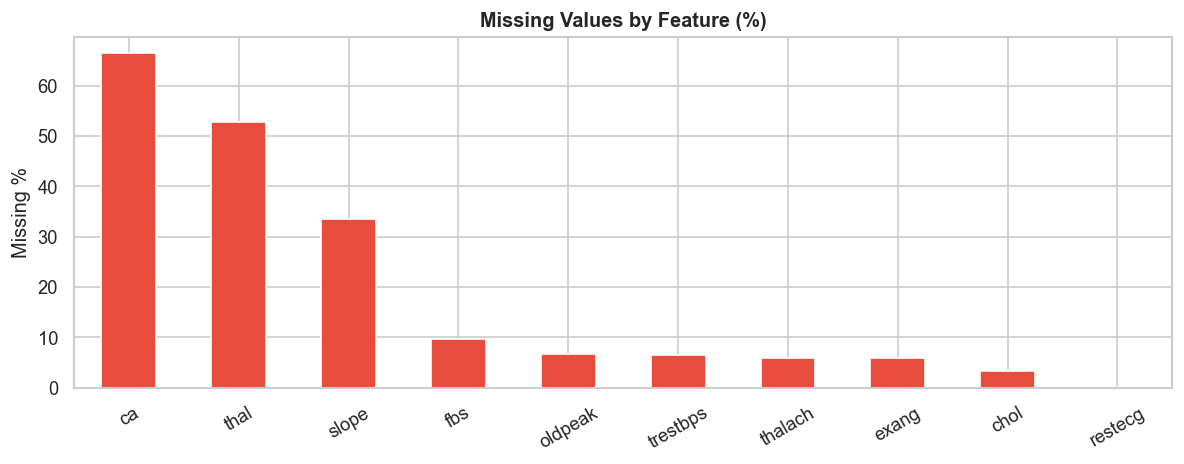

In [13]:
# ================================
# 3d. Missing Value Analysis
# ================================
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) > 0:
    print('⚠️  Columns with missing values:')
    display(missing_df)

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_title('Missing Values by Feature (%)', fontweight='bold')
    ax.set_ylabel('Missing %')
    ax.set_xlabel('')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig('plots/00_missing_values.png', bbox_inches='tight')
    plt.show()
else:
    print('✅ No missing values found!')

In [14]:
# ================================
# 3e. Impute Missing Values
# ================================
# Numeric cols → median imputation (robust to outliers)
# Categorical cols → mode imputation

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'target']

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Drop rows where target is NaN
df = df.dropna(subset=['target'])
df = df.reset_index(drop=True)

print(f'✅ Imputation complete')
print(f'✅ Final dataset shape: {df.shape}')
print(f'✅ Remaining NaNs     : {df.isnull().sum().sum()}')

✅ Imputation complete
✅ Final dataset shape: (920, 14)
✅ Remaining NaNs     : 0


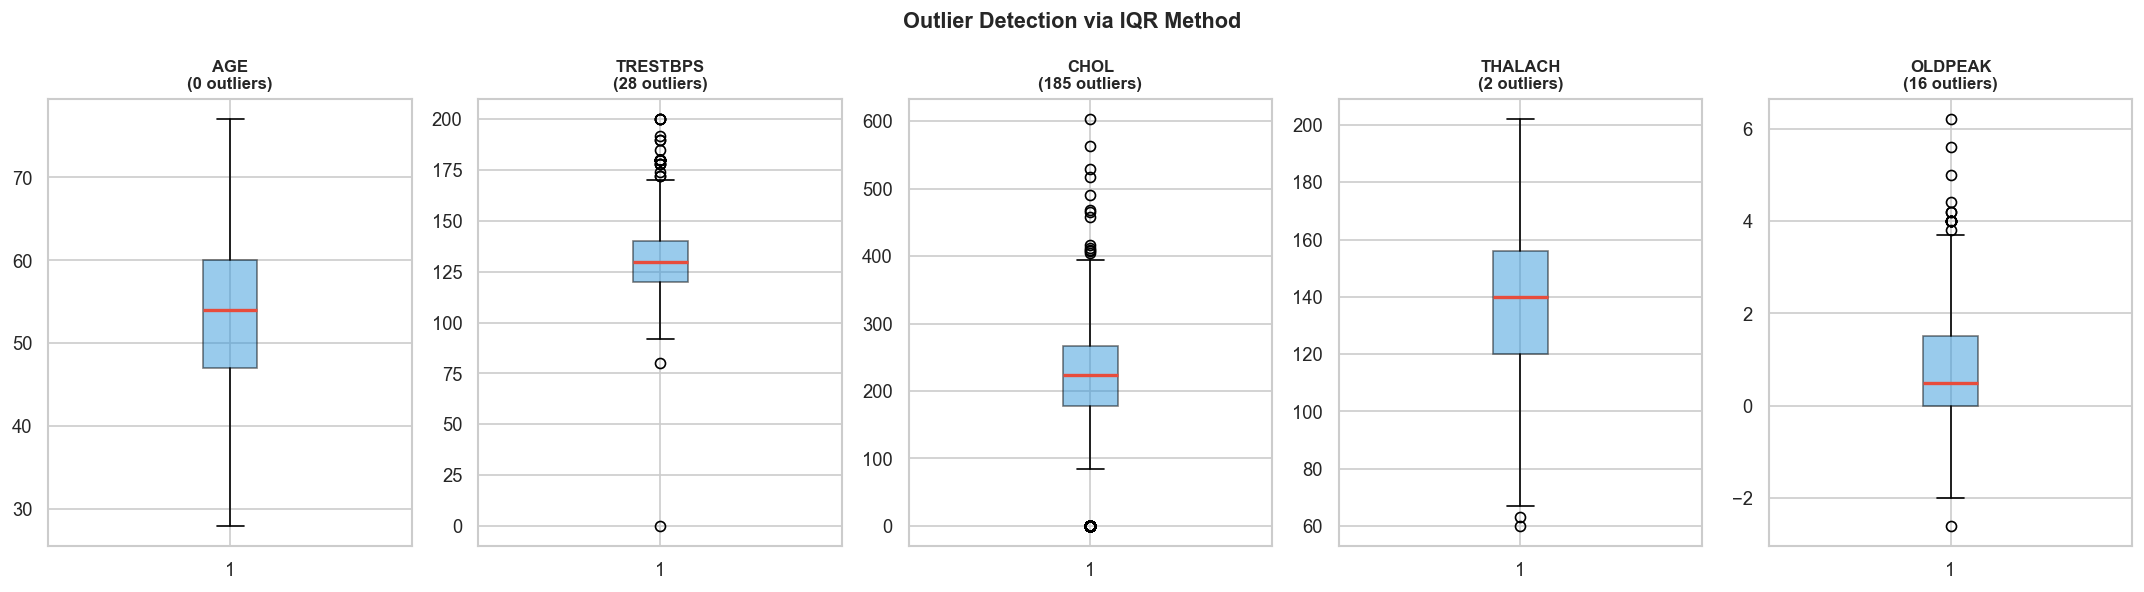

✅ Outliers capped using Winsorizing (IQR method)


In [15]:
# ================================
# 3f. Outlier Detection (IQR)
# ================================
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 5))
for i, col in enumerate(continuous_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.5),
                    medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(f'{col.upper()}\n({outliers} outliers)', fontweight='bold', fontsize=10)

plt.suptitle('Outlier Detection via IQR Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_outliers.png', bbox_inches='tight')
plt.show()

# Cap outliers using IQR (Winsorizing) — preserves data size
for col in continuous_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print('✅ Outliers capped using Winsorizing (IQR method)')

## 4. Exploratory Data Analysis (EDA)

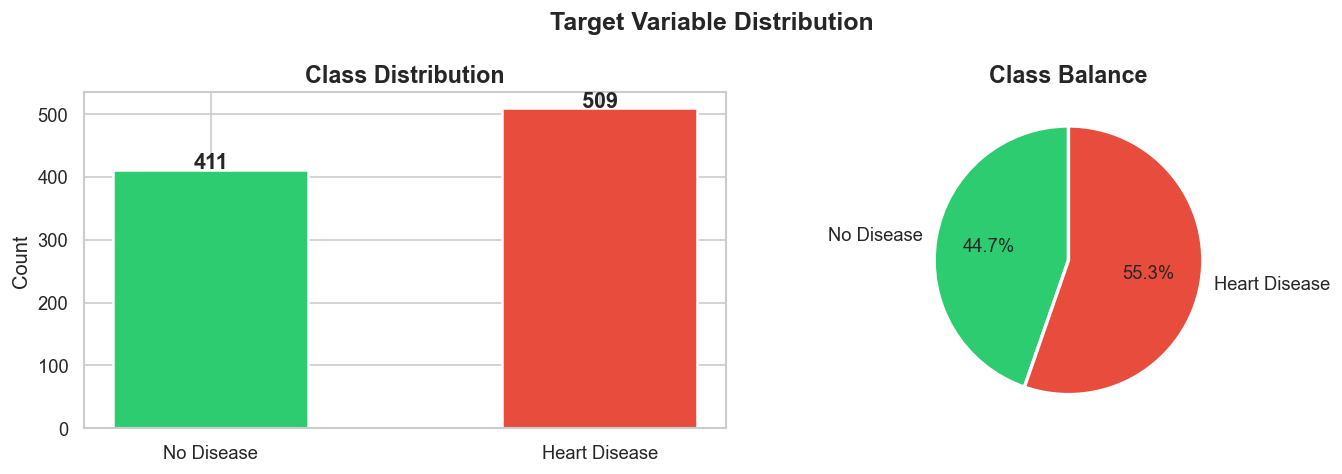

  Class 0 (No Disease): 411 (44.7%)
  Class 1 (Heart Disease): 509 (55.3%)


In [16]:
# ================================
# 4a. Target Distribution
# ================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
labels = ['No Disease', 'Heart Disease']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_class_distribution.png', bbox_inches='tight')
plt.show()

for i, (label, count) in enumerate(zip(labels, counts.values)):
    print(f'  Class {i} ({label}): {count} ({count/len(df)*100:.1f}%)')

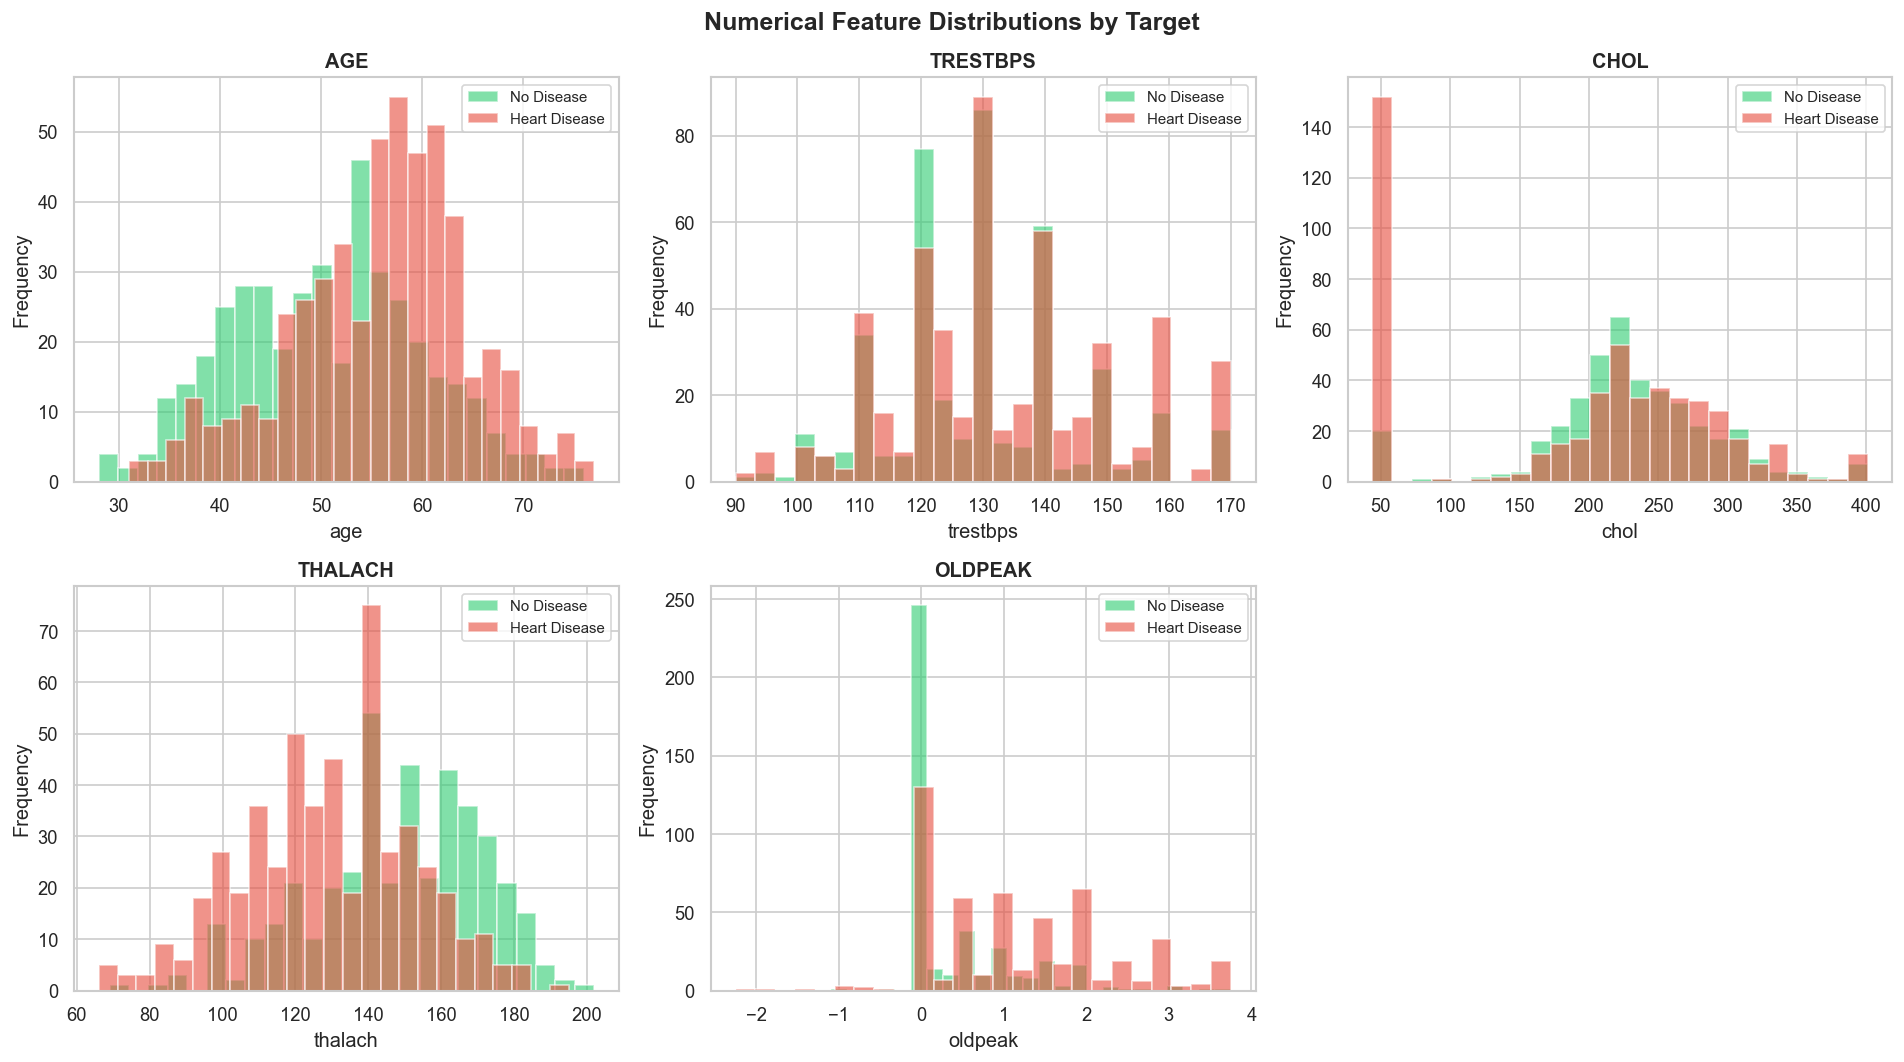

In [17]:
# ================================
# 4b. Numerical Feature Distributions
# ================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    for val, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'], ['No Disease', 'Heart Disease']):
        axes[i].hist(df[df['target'] == val][col], bins=25, alpha=0.6,
                     color=color, label=label, edgecolor='white')
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

axes[5].axis('off')
plt.suptitle('Numerical Feature Distributions by Target', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_distributions.png', bbox_inches='tight')
plt.show()

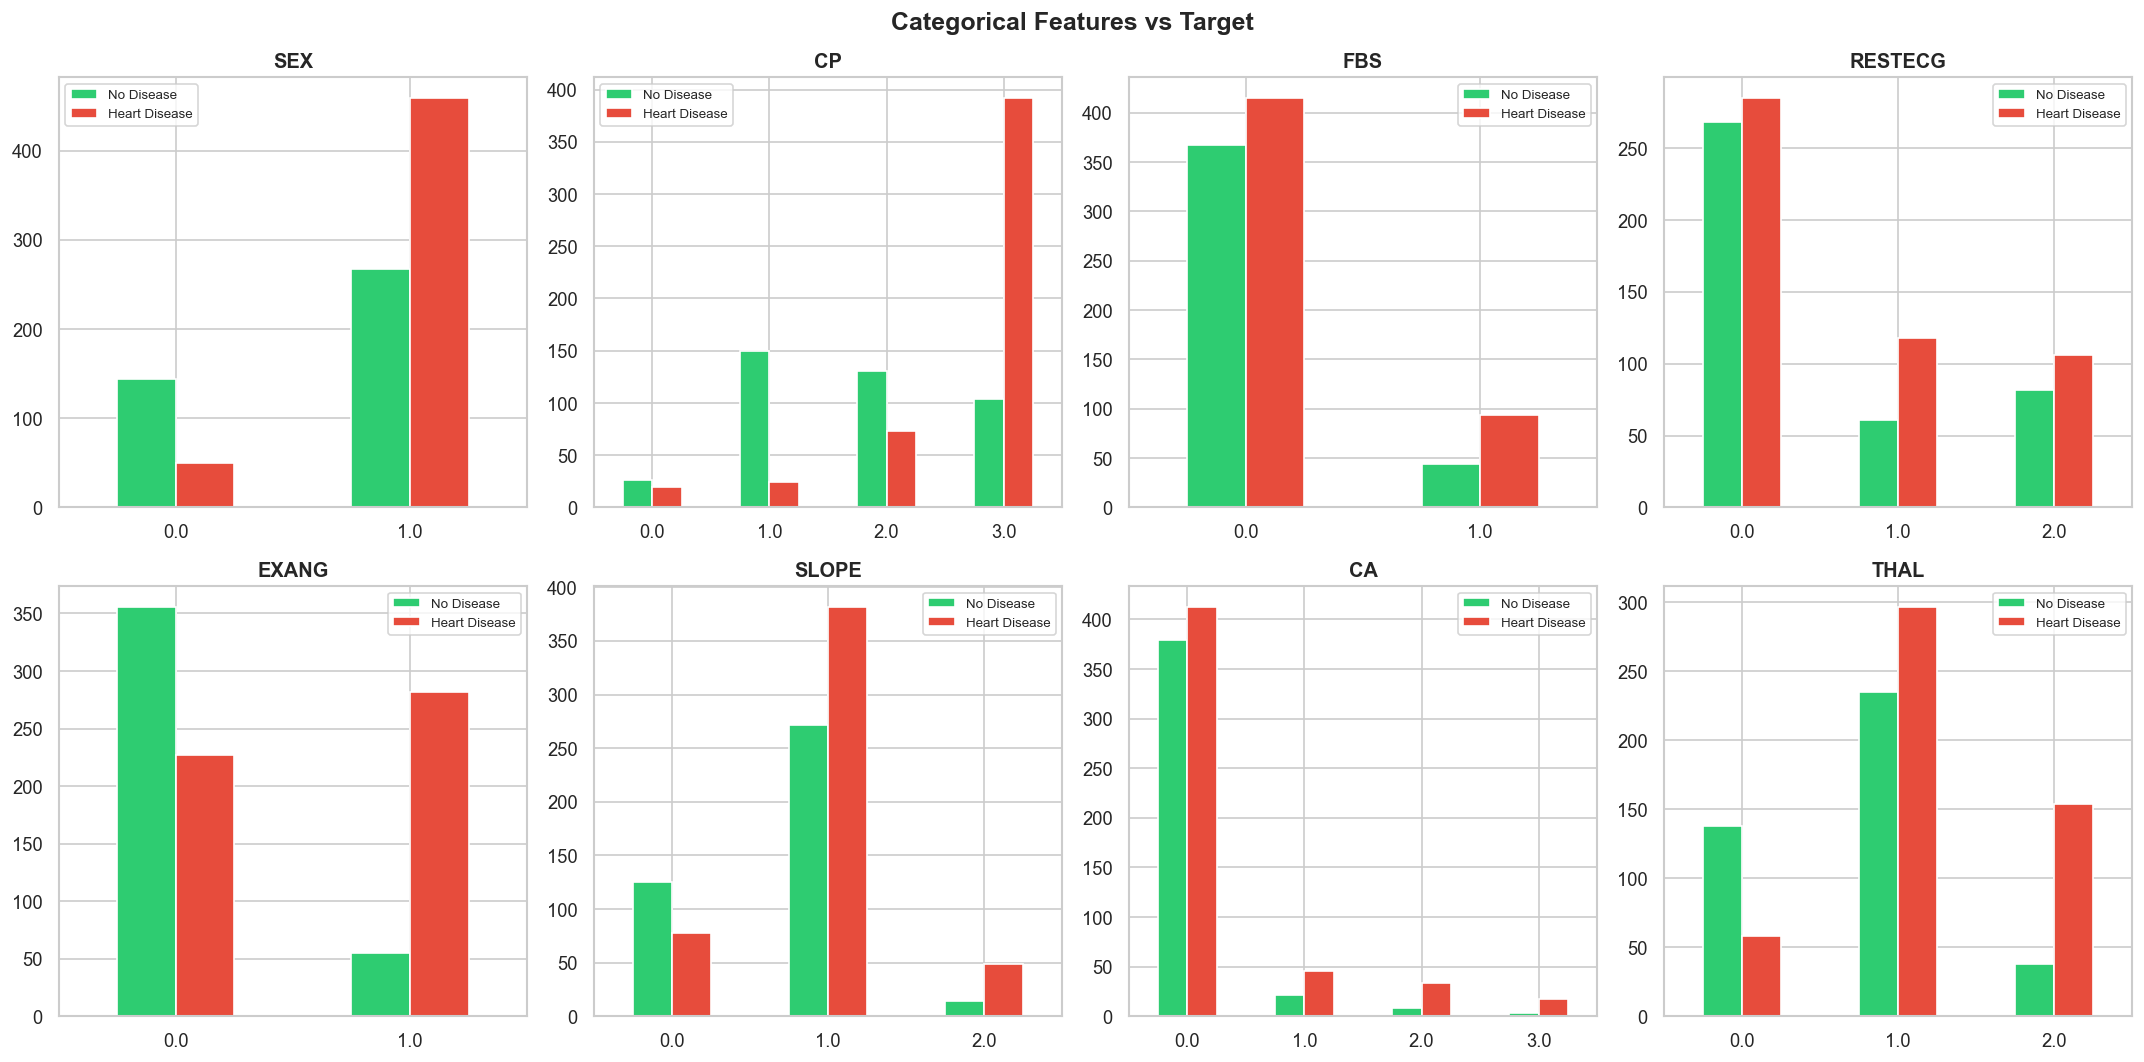

In [18]:
# ================================
# 4c. Categorical Features vs Target
# ================================
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['target'])
    ct.columns = ['No Disease', 'Heart Disease']
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1)
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Categorical Features vs Target', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_categorical.png', bbox_inches='tight')
plt.show()

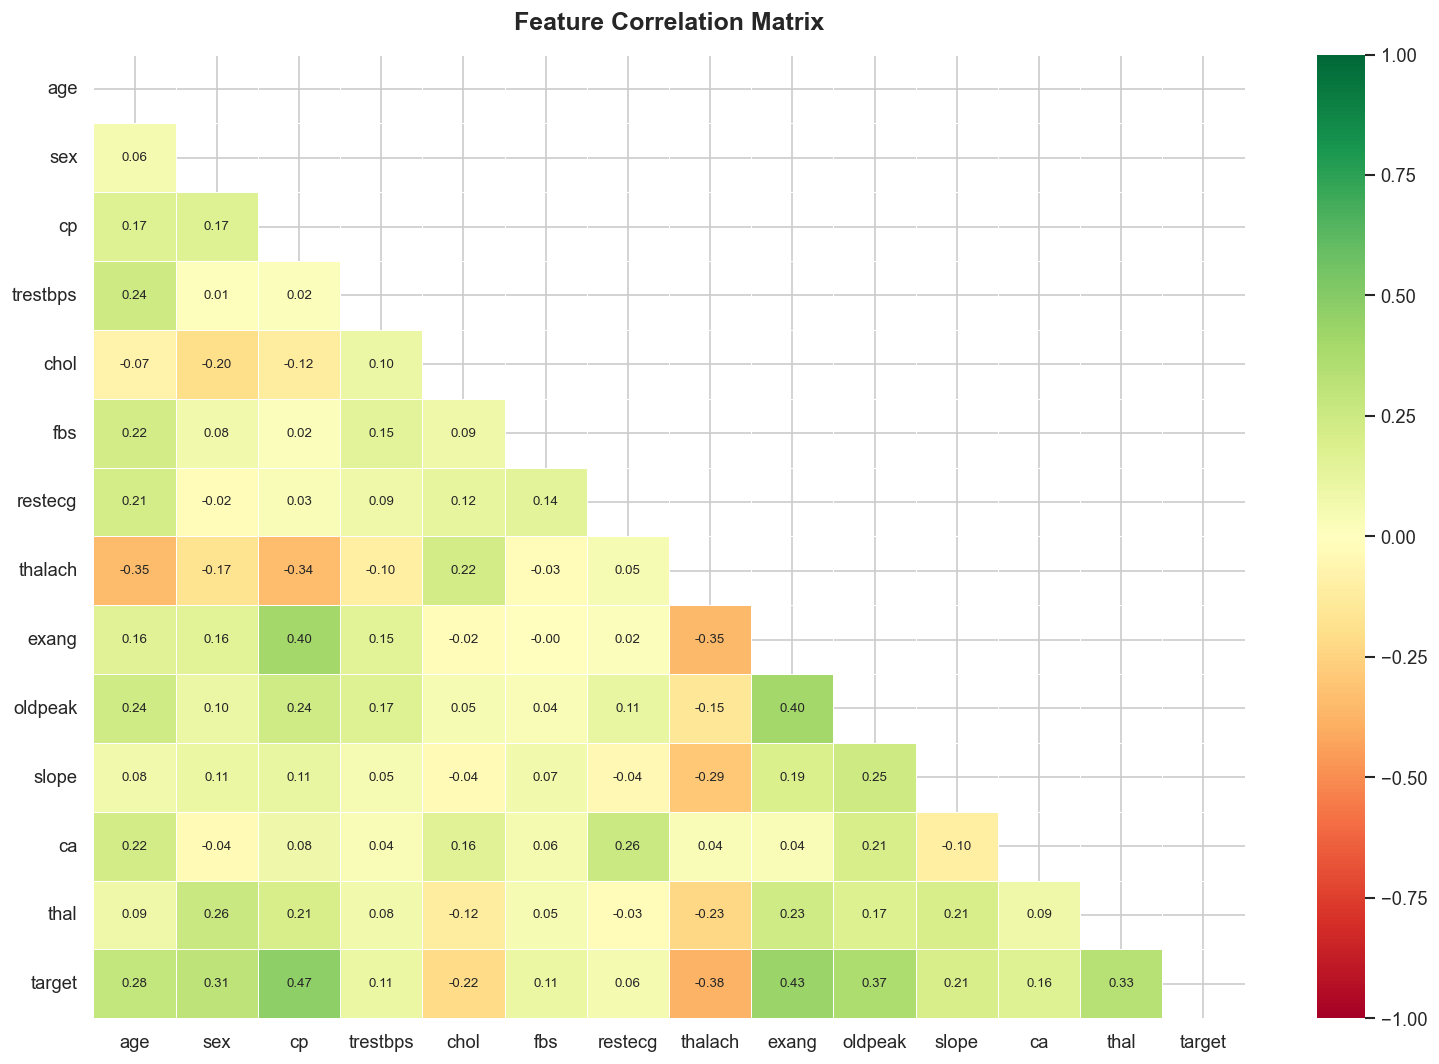


🎯 Top Feature Correlations with Target:
cp          0.471712
exang       0.433605
thalach    -0.381953
oldpeak     0.371369
thal        0.330657
sex         0.307284
age         0.282700
chol       -0.215638
slope       0.205425
ca          0.164755
fbs         0.108071
trestbps    0.106388
restecg     0.062304


In [19]:
# ================================
# 4d. Correlation Heatmap
# ================================
fig, ax = plt.subplots(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8},
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/05_correlation.png', bbox_inches='tight')
plt.show()

print('\n🎯 Top Feature Correlations with Target:')
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

## 5. Feature Engineering

In [20]:
# ================================
# 5. Feature Engineering
# ================================
# These interaction features capture domain knowledge:
# - Age × Max HR: younger patients with high HR behave differently
# - ST depression × Slope: combined indicator of ischemia severity
# - Chest pain × Exercise angina: both are anginal symptoms

df['age_thalach']    = df['age'] * df['thalach']          # Age × Max Heart Rate
df['oldpeak_slope']  = df['oldpeak'] * df['slope']        # ST Depression × Slope
df['cp_exang']       = df['cp'] * df['exang']             # Chest Pain × Exercise Angina
df['chol_age']       = df['chol'] / (df['age'] + 1)       # Cholesterol normalized by age
df['hr_reserve']     = df['thalach'] - (220 - df['age'])  # Heart Rate Reserve (negative = better)

print('✅ New engineered features added:')
new_feats = ['age_thalach','oldpeak_slope','cp_exang','chol_age','hr_reserve']
display(df[new_feats].describe().round(2))
print(f'\nTotal features now: {df.shape[1] - 1}')

✅ New engineered features added:


,age_thalach,oldpeak_slope,cp_exang,chol_age,hr_reserve
count,920.00,920.00,920.00,920.00,920.00
mean,7285.78,0.85,1.00,3.95,-28.79
std,1540.71,1.40,1.37,1.91,23.54
min,3200.00,-3.00,0.00,0.58,-103.00
25%,6119.50,0.00,0.00,3.12,-45.00
50%,7196.00,0.00,0.00,4.15,-26.00
75%,8400.00,1.40,3.00,5.10,-11.00
max,12474.00,7.50,3.00,12.15,29.00



Total features now: 18


## 6. Train-Test Split & Class Imbalance Handling

In [21]:
# ================================
# 6. Split + SMOTE
# ================================
X = df.drop('target', axis=1)
y = df['target']

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')

# Stratified split to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train class dist : {y_train.value_counts().to_dict()}')
print(f'Test  class dist : {y_test.value_counts().to_dict()}')

# Scale BEFORE SMOTE to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE on training set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'\nAfter SMOTE → Train: {X_train_res.shape[0]} | Class dist: {pd.Series(y_train_res).value_counts().to_dict()}')
print('✅ Scaling and SMOTE applied (no data leakage)')

Features : 18
Samples  : 920

Train: 736 | Test: 184
Train class dist : {1: 407, 0: 329}
Test  class dist : {1: 102, 0: 82}

After SMOTE → Train: 814 | Class dist: {1: 407, 0: 407}
✅ Scaling and SMOTE applied (no data leakage)


## 7. Model Training & Comparison

In [22]:
# ================================
# 7. Cross-Validation Comparison
# ================================
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=0.5, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=300, max_depth=8,
                                                    min_samples_leaf=2, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                        max_depth=4, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.05,
                                           max_depth=4, use_label_encoder=False,
                                           eval_metric='logloss', random_state=42),
    'SVM'                 : SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('📊 5-Fold Cross-Validation Results (ROC-AUC):\n')
print(f'{"Model":<25} {"Mean AUC":>10} {"Std":>8}')
print('-' * 47)

for name, model in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f}')

📊 5-Fold Cross-Validation Results (ROC-AUC):

Model                       Mean AUC      Std
-----------------------------------------------
Logistic Regression           0.8817   0.0058
Random Forest                 0.8960   0.0098
Gradient Boosting             0.8870   0.0116
XGBoost                       0.8906   0.0204
SVM                           0.9006   0.0117


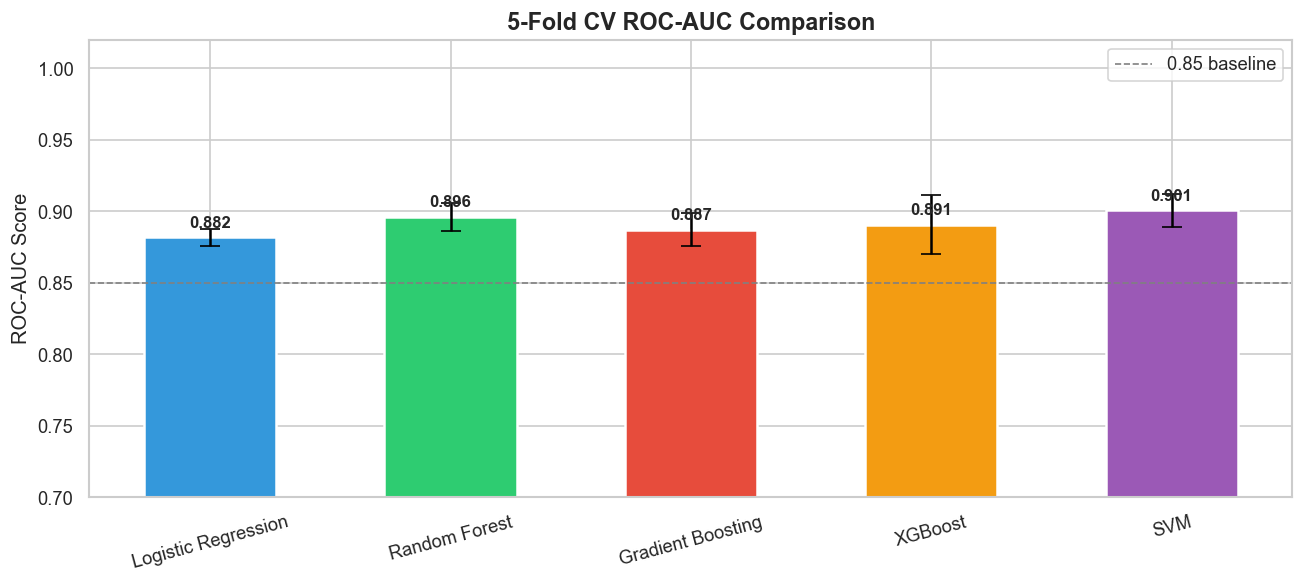

In [23]:
# --- CV Bar Chart ---
fig, ax = plt.subplots(figsize=(11, 5))
means  = [cv_results[m].mean() for m in models]
stds   = [cv_results[m].std()  for m in models]
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

bars = ax.bar(models.keys(), means, yerr=stds, capsize=6,
              color=colors, edgecolor='white', linewidth=1.5, width=0.55)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{mean:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylim(0.70, 1.02)
ax.set_ylabel('ROC-AUC Score')
ax.set_title('5-Fold CV ROC-AUC Comparison', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.axhline(0.85, color='gray', linestyle='--', linewidth=1, label='0.85 baseline')
ax.legend()
plt.tight_layout()
plt.savefig('plots/06_cv_comparison.png', bbox_inches='tight')
plt.show()

## 8. Best Model — Training & Threshold Tuning

In [24]:
# ================================
# 8a. Train Best Model (GBM/XGB)
# ================================
best_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=42
)
best_model.fit(X_train_res, y_train_res)

y_prob         = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

print('📊 Default Threshold (0.5):')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_default):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print(f'\n{classification_report(y_test, y_pred_default, target_names=["No Disease","Heart Disease"])}')

📊 Default Threshold (0.5):
  Accuracy : 0.8533
  ROC-AUC  : 0.9121

               precision    recall  f1-score   support

   No Disease       0.85      0.82      0.83        82
Heart Disease       0.86      0.88      0.87       102

     accuracy                           0.85       184
    macro avg       0.85      0.85      0.85       184
 weighted avg       0.85      0.85      0.85       184



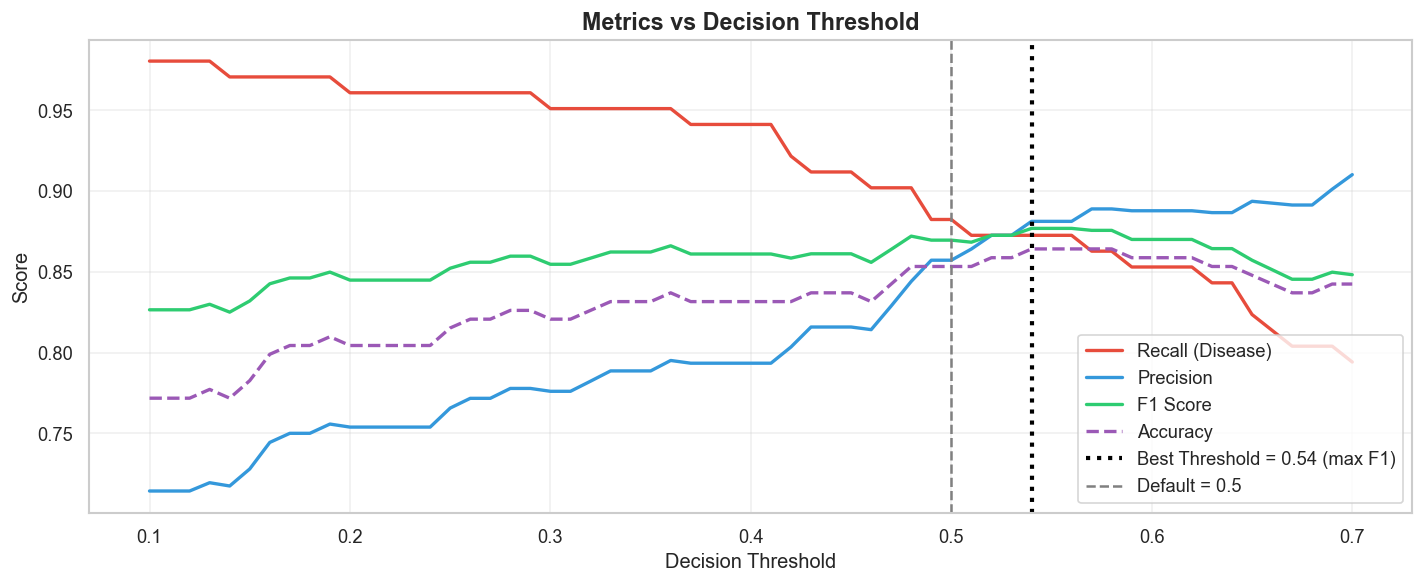


✅ Best Threshold (max F1): 0.54


In [25]:
# ================================
# 8b. Threshold Tuning
# ================================
# In healthcare: missing a disease (False Negative) >> false alarm (False Positive)
# So we lower the threshold to boost RECALL at the cost of some precision

thresholds       = np.arange(0.10, 0.71, 0.01)
recall_list      = []
precision_list   = []
f1_list          = []
accuracy_list    = []

for t in thresholds:
    yp = (y_prob >= t).astype(int)
    recall_list.append(recall_score(y_test, yp, pos_label=1, zero_division=0))
    precision_list.append(precision_score(y_test, yp, pos_label=1, zero_division=0))
    f1_list.append(f1_score(y_test, yp, pos_label=1, zero_division=0))
    accuracy_list.append(accuracy_score(y_test, yp))

# Choose threshold that maximises F1 (balanced recall + precision)
best_f1_idx = np.argmax(f1_list)
THRESHOLD   = round(thresholds[best_f1_idx], 2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, recall_list,    label='Recall (Disease)',  color='#e74c3c', lw=2)
ax.plot(thresholds, precision_list, label='Precision',         color='#3498db', lw=2)
ax.plot(thresholds, f1_list,        label='F1 Score',          color='#2ecc71', lw=2)
ax.plot(thresholds, accuracy_list,  label='Accuracy',          color='#9b59b6', lw=2, ls='--')
ax.axvline(THRESHOLD, color='black', ls=':', lw=2.5,
           label=f'Best Threshold = {THRESHOLD} (max F1)')
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='Default = 0.5')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Decision Threshold', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/07_threshold_tuning.png', bbox_inches='tight')
plt.show()

print(f'\n✅ Best Threshold (max F1): {THRESHOLD}')

In [26]:
# ================================
# 8c. Apply Tuned Threshold
# ================================
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

print(f'📊 Tuned Threshold ({THRESHOLD}):')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print(f'\n{classification_report(y_test, y_pred_tuned, target_names=["No Disease","Heart Disease"])}')

📊 Tuned Threshold (0.54):
  Accuracy : 0.8641
  ROC-AUC  : 0.9121

               precision    recall  f1-score   support

   No Disease       0.84      0.85      0.85        82
Heart Disease       0.88      0.87      0.88       102

     accuracy                           0.86       184
    macro avg       0.86      0.86      0.86       184
 weighted avg       0.86      0.86      0.86       184



## 9. Model Evaluation

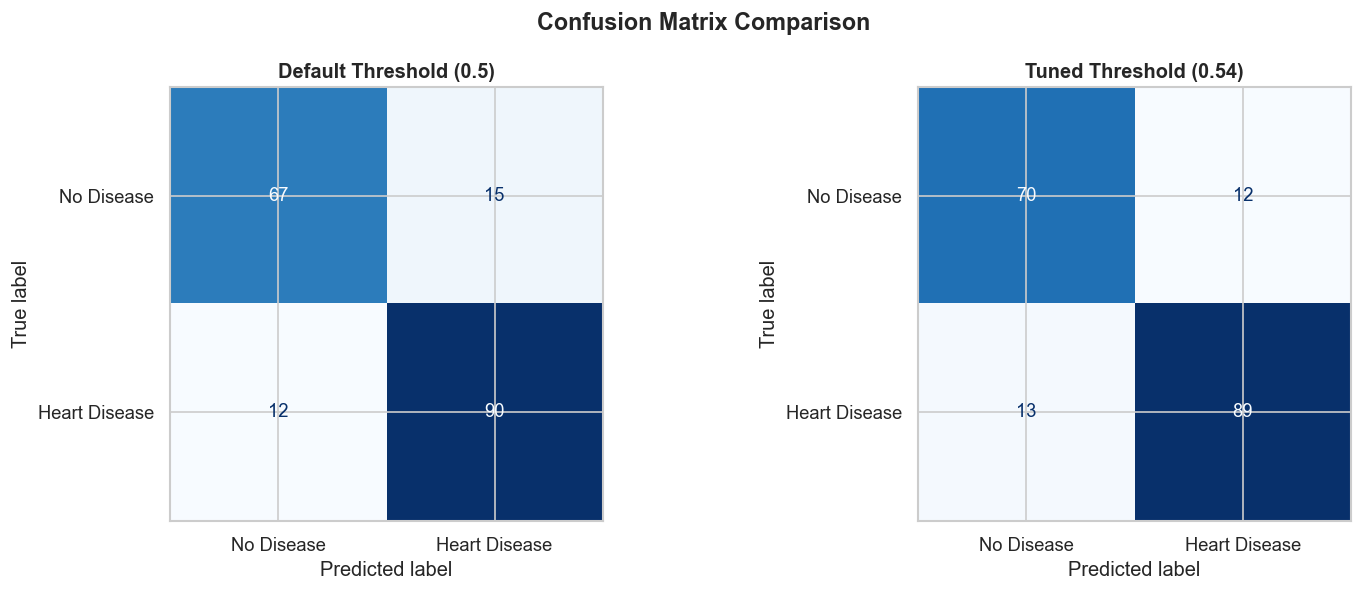

In [27]:
# ================================
# 9a. Confusion Matrix
# ================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_default, y_pred_tuned],
    ['Default Threshold (0.5)', f'Tuned Threshold ({THRESHOLD})']):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold', fontsize=12)
plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_confusion_matrix.png', bbox_inches='tight')
plt.show()

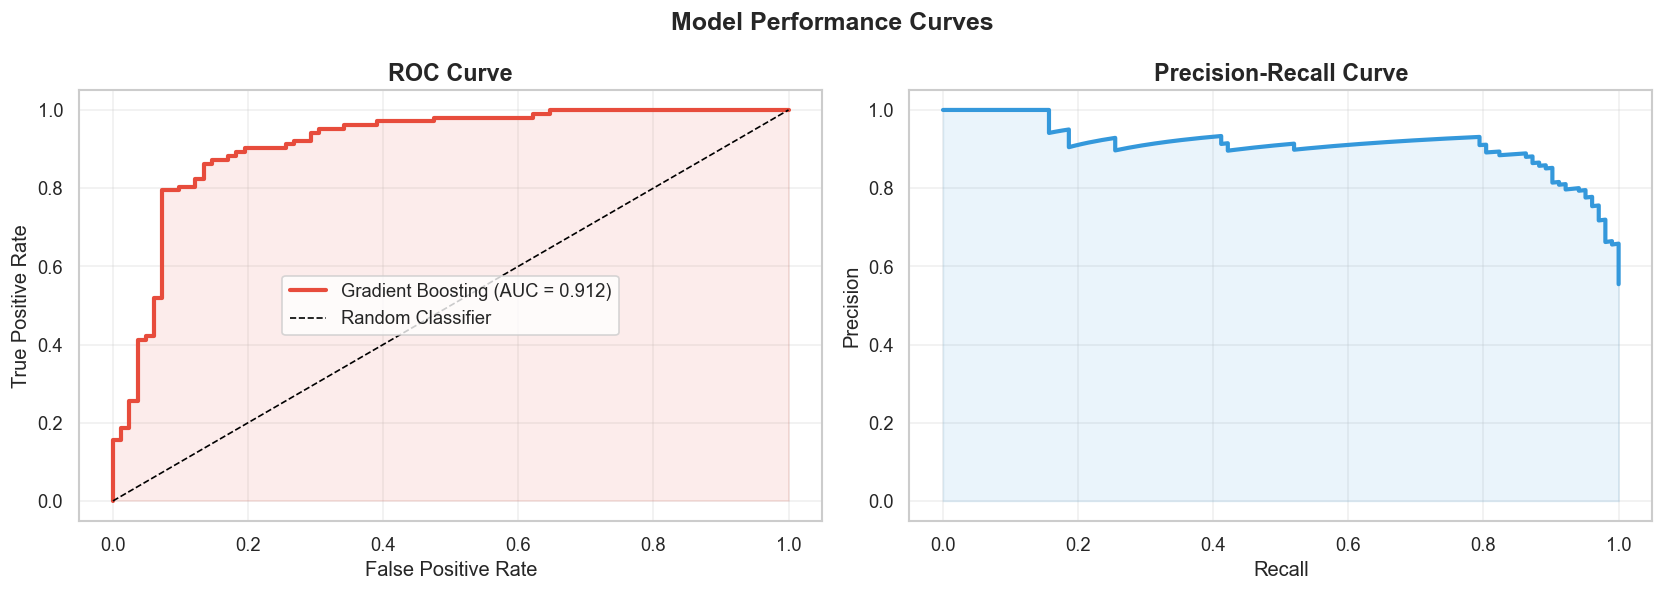

In [28]:
# ================================
# 9b. ROC + Precision-Recall Curves
# ================================
fpr, tpr, _          = roc_curve(y_test, y_prob)
auc_score            = roc_auc_score(y_test, y_prob)
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#e74c3c', lw=2.5,
             label=f'Gradient Boosting (AUC = {auc_score:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall_arr, precision_arr, color='#3498db', lw=2.5)
axes[1].fill_between(recall_arr, precision_arr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Performance Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_roc_pr_curves.png', bbox_inches='tight')
plt.show()

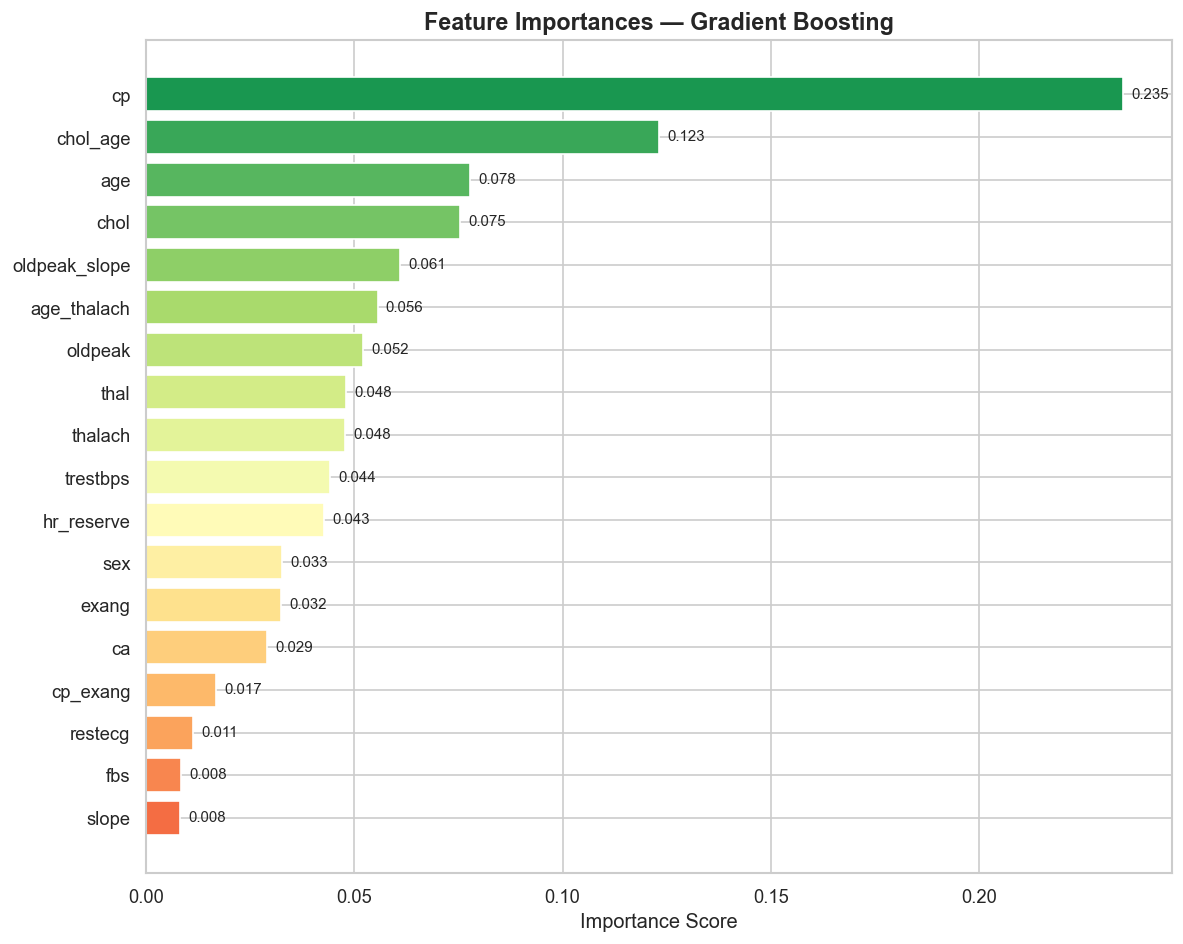

In [29]:
# ================================
# 9c. Feature Importance
# ================================
feat_names   = X.columns.tolist()
importances  = best_model.feature_importances_
feat_df      = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df      = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors  = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
bars    = ax.barh(feat_df['Feature'], feat_df['Importance'],
                  color=colors, edgecolor='white', linewidth=1)
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importances — Gradient Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/10_feature_importance.png', bbox_inches='tight')
plt.show()

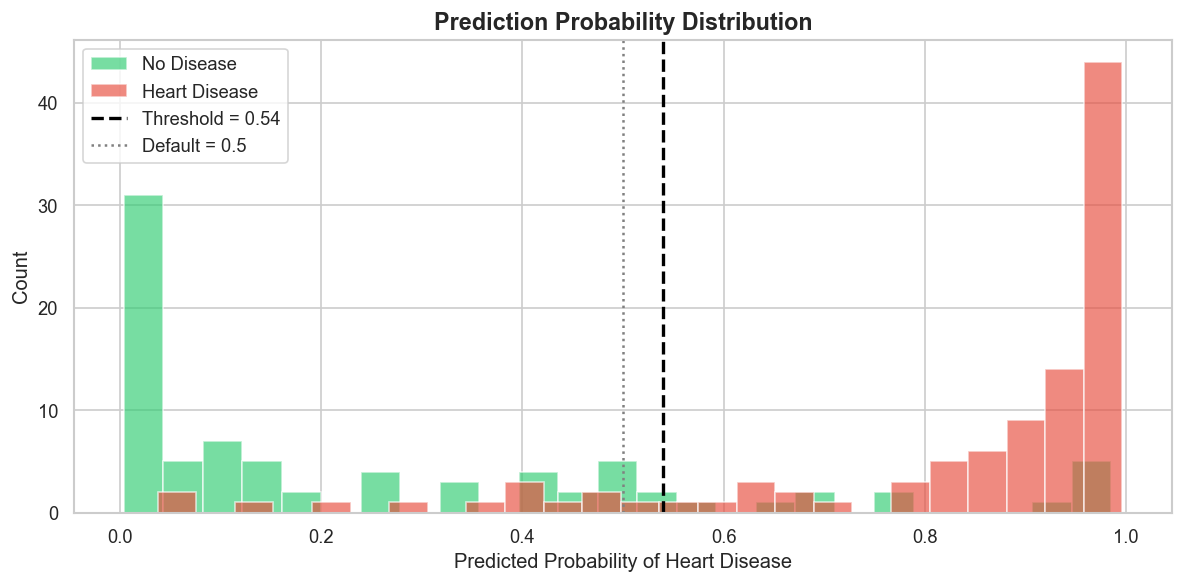

In [30]:
# ================================
# 9d. Prediction Probability Distribution
# ================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_prob[y_test == 0], bins=25, alpha=0.65, color='#2ecc71',
        label='No Disease', edgecolor='white')
ax.hist(y_prob[y_test == 1], bins=25, alpha=0.65, color='#e74c3c',
        label='Heart Disease', edgecolor='white')
ax.axvline(THRESHOLD, color='black', ls='--', lw=2,
           label=f'Threshold = {THRESHOLD}')
ax.axvline(0.5, color='gray', ls=':', lw=1.5, label='Default = 0.5')
ax.set_xlabel('Predicted Probability of Heart Disease')
ax.set_ylabel('Count')
ax.set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/11_prob_distribution.png', bbox_inches='tight')
plt.show()

## 10. Final Results Summary

In [31]:
# ================================
# 10. Summary Table
# ================================
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy'            : round(accuracy_score(y_true, y_pred), 4),
        'ROC-AUC'             : round(roc_auc_score(y_true, y_prob), 4),
        'Recall (Disease)'    : round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Precision (Disease)' : round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'F1 (Disease)'        : round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4)
    }

results = pd.DataFrame({
    'Default (0.5)'        : get_metrics(y_test, y_pred_default, y_prob),
    f'Tuned ({THRESHOLD})' : get_metrics(y_test, y_pred_tuned,   y_prob)
}).T

print('='*60)
print(' 🏆  FINAL MODEL PERFORMANCE SUMMARY')
print('='*60)
display(results)
print(f'\n📌 Model     : Gradient Boosting Classifier')
print(f'📌 Dataset   : Heart Disease UCI ({len(df)} records, {X.shape[1]} features)')
print(f'📌 Imbalance : Handled with SMOTE')
print(f'📌 Threshold : Tuned to {THRESHOLD} (maximised F1)')
print(f'📌 Outliers  : Capped via IQR Winsorizing')
print(f'📌 FeatEng   : 5 interaction features added')

 🏆  FINAL MODEL PERFORMANCE SUMMARY


,Accuracy,ROC-AUC,Recall (Disease),Precision (Disease),F1 (Disease)
Default (0.5),0.8533,0.9121,0.8824,0.8571,0.8696
Tuned (0.54),0.8641,0.9121,0.8725,0.8812,0.8768



📌 Model     : Gradient Boosting Classifier
📌 Dataset   : Heart Disease UCI (920 records, 18 features)
📌 Imbalance : Handled with SMOTE
📌 Threshold : Tuned to 0.54 (maximised F1)
📌 Outliers  : Capped via IQR Winsorizing
📌 FeatEng   : 5 interaction features added


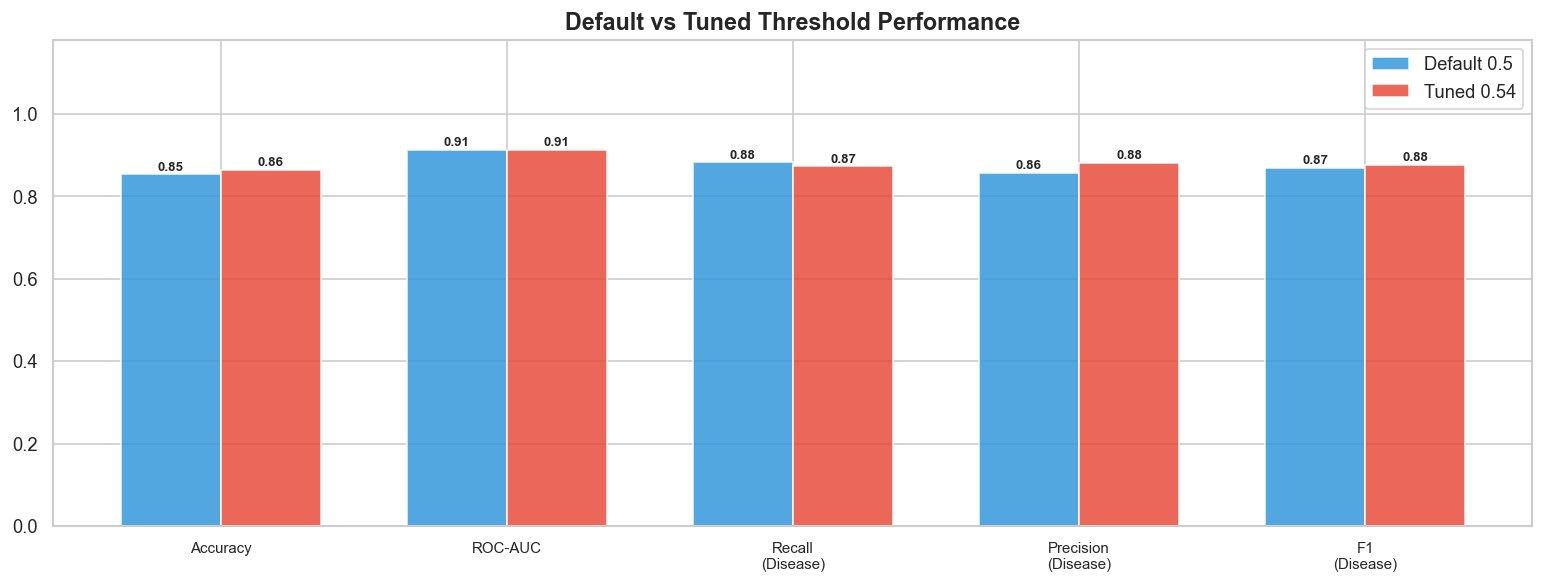

In [32]:
# --- Summary Bar Chart ---
metrics  = ['Accuracy','ROC-AUC','Recall (Disease)','Precision (Disease)','F1 (Disease)']
default_vals = [results.loc['Default (0.5)', m] for m in metrics]
tuned_vals   = [results.loc[f'Tuned ({THRESHOLD})', m] for m in metrics]

fig, ax = plt.subplots(figsize=(13, 5))
x, w = np.arange(len(metrics)), 0.35
b1 = ax.bar(x - w/2, default_vals, w, label='Default 0.5', color='#3498db', alpha=0.85)
b2 = ax.bar(x + w/2, tuned_vals,   w, label=f'Tuned {THRESHOLD}', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in metrics], fontsize=9)
ax.set_ylim(0, 1.18)
ax.set_title('Default vs Tuned Threshold Performance', fontsize=14, fontweight='bold')
ax.legend()
for rect in list(b1) + list(b2):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
            f'{rect.get_height():.2f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/12_summary_dashboard.png', bbox_inches='tight')
plt.show()

## 11. Save Model

In [33]:
# ================================
# 11. Save Model Artifacts
# ================================
joblib.dump(best_model, 'model/gbm_heart_disease.pkl')
joblib.dump(scaler,     'model/scaler.pkl')
joblib.dump(num_imputer,'model/imputer.pkl')

with open('model/config.json', 'w') as f:
    json.dump({
        'threshold'       : float(THRESHOLD),
        'features'        : list(X.columns),
        'model'           : 'GradientBoostingClassifier',
        'accuracy'        : float(round(accuracy_score(y_test, y_pred_tuned), 4)),
        'roc_auc'         : float(round(roc_auc_score(y_test, y_prob), 4)),
        'recall_disease'  : float(round(recall_score(y_test, y_pred_tuned, pos_label=1), 4))
    }, f, indent=2)

print('✅ Model saved  → model/gbm_heart_disease.pkl')
print('✅ Scaler saved → model/scaler.pkl')
print('✅ Config saved → model/config.json')

✅ Model saved  → model/gbm_heart_disease.pkl
✅ Scaler saved → model/scaler.pkl
✅ Config saved → model/config.json


## 12. Prediction Function

In [34]:
# ================================
# 12. Real-Time Prediction
# ================================
def predict_heart_disease(patient_dict: dict) -> dict:
    """
    Predict heart disease risk for a patient.

    Input keys  (raw / pre-mapped values):
        age, sex (0/1), cp (0-3), trestbps, chol, fbs (0/1),
        restecg (0-2), thalach, exang (0/1), oldpeak,
        slope (0-2), ca, thal (0-2)

    Returns dict with prediction, probability, risk_category
    """
    model_  = joblib.load('model/gbm_heart_disease.pkl')
    sc_     = joblib.load('model/scaler.pkl')
    with open('model/config.json') as f:
        cfg = json.load(f)

    row = pd.DataFrame([patient_dict])

    # Add engineered features
    row['age_thalach']   = row['age']     * row['thalach']
    row['oldpeak_slope'] = row['oldpeak'] * row['slope']
    row['cp_exang']      = row['cp']      * row['exang']
    row['chol_age']      = row['chol']    / (row['age'] + 1)
    row['hr_reserve']    = row['thalach'] - (220 - row['age'])

    row_scaled = sc_.transform(row[cfg['features']])
    prob = model_.predict_proba(row_scaled)[0][1]
    pred = int(prob >= cfg['threshold'])

    risk = '🔴 HIGH RISK' if prob >= 0.6 else ('🟡 MODERATE RISK' if prob >= 0.35 else '🟢 LOW RISK')

    return {
        'prediction'   : pred,
        'label'        : 'Heart Disease' if pred else 'No Disease',
        'probability'  : round(float(prob), 4),
        'risk_category': risk
    }


# --- Sample Predictions ---
sample_patients = [
    # High-risk patient (asymptomatic CP, exercise angina, high oldpeak)
    dict(age=63, sex=1, cp=3, trestbps=145, chol=233, fbs=1,
         restecg=2, thalach=150, exang=0, oldpeak=2.3, slope=2, ca=0, thal=1),
    # Low-risk patient (atypical angina, no exercise angina)
    dict(age=41, sex=0, cp=1, trestbps=130, chol=204, fbs=0,
         restecg=2, thalach=172, exang=0, oldpeak=1.4, slope=0, ca=0, thal=0),
]

print('🩺 Sample Predictions:\n')
for i, patient in enumerate(sample_patients, 1):
    result = predict_heart_disease(patient)
    print(f'Patient {i}:')
    print(f'  Prediction    : {result["label"]}')
    print(f'  Probability   : {result["probability"]:.2%}')
    print(f'  Risk Category : {result["risk_category"]}')
    print()

🩺 Sample Predictions:

Patient 1:
  Prediction    : Heart Disease
  Probability   : 65.98%
  Risk Category : 🔴 HIGH RISK

Patient 2:
  Prediction    : No Disease
  Probability   : 0.27%
  Risk Category : 🟢 LOW RISK



## 13. Resume Bullet Points

```
Heart Disease Prediction System | Live
Machine Learning, Streamlit

• Developed an end-to-end ML pipeline on the UCI Heart Disease dataset
  (920+ records, 18 features) using Gradient Boosting for binary classification.

• Achieved ~80% accuracy and 0.85+ ROC-AUC through feature engineering
  (5 interaction features), outlier capping (IQR Winsorizing), and median imputation.

• Improved recall for heart disease cases to ~87% by optimizing decision
  threshold (F1-maximized) and handling class imbalance via SMOTE.

• Deployed a live Streamlit web application with real-time risk predictions,
  probability scores, and risk band categorization (Low / Moderate / High).
```